# Oracle prediction from hybrid simulation

This notebook does three things:
1. Build topic innovations from empirical topic data.
2. Simulate returns using the `multivariate_CGL_offline_lasso` logic (from `Theory/simulate_Lasso.ipynb`) but with topic innovations as `X`.
3. Re-estimate the model with the same `lambda` and `window_size` to test parameter recovery.

It runs first on 20 topics, then on the full topic set.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats.mstats import winsorize
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Locate repository root and estimation directory
current = Path.cwd().resolve()
repo_root = next((p for p in [current, *current.parents] if (p / 'Empirical').exists() and (p / 'Theory').exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not locate repository root containing 'Empirical' and 'Theory'.")

estimation_dir = repo_root / 'Empirical' / 'estimation'
if str(estimation_dir) not in sys.path:
    sys.path.insert(0, str(estimation_dir))
os.chdir(estimation_dir)

import stage1 as stage1_module
stage1_module.sm = sm

from stage1 import to_ar1_innovations
from grid_search import estimate_single_config

In [2]:
# Structural parameters (same calibration used in theory notebooks)
a = 1.55
gamma = 2.0
sigma = 0.001
delta = 0.9
phi = np.exp(sigma**2 / 2)
kappa = delta * a ** (-gamma) * phi
w = -np.log(kappa) - np.exp(-10)

window_size = 100
n_lags = 1
correct_with_tanh = True
standardize_features = False

print(f'kappa={kappa:.6f}, w={w:.6f}, window={window_size}, standardize={standardize_features}')

kappa=0.374610, w=0.981824, window=100, standardize=False


In [3]:
# Build topic innovations (X candidate)
topics = pd.read_csv(repo_root / 'Empirical' / 'data' / 'merged_return_topic_data.csv')
topics = topics[[col for col in topics.columns if not any(char.isdigit() for char in col)]]
topics.set_index('date', inplace=True)
topics = to_ar1_innovations(topics)
topics = topics.iloc[1:]
topics = topics.apply(lambda col: winsorize(col, limits=[0.01, 0.01]))
topics = topics.astype(float)
topics = topics.dropna(axis=0, how='any')

# Standardize topics once, then use the same standardized X in simulation and estimation
if standardize_features:
    scaler_topics = StandardScaler()
    topics = pd.DataFrame(
        scaler_topics.fit_transform(topics),
        index=topics.index,
        columns=topics.columns
    )

print(f'Topic innovation matrix shape: {topics.shape}')
print(f'Average variance after preprocessing: {float(topics.var().mean()):.6f}')

Topic innovation matrix shape: (1888, 180)
Average variance after preprocessing: 0.000008


In [4]:
# Lambda calibration: back out lambda from the theoretical stationary distribution of beta.
# For rolling-window OLS with window W, the theory gives:
#   sd_beta = sigma_d * sqrt((1-kappa)/2) / (sigma_x * sqrt(W))
# We set lambda such that a null topic is selected with probability target_selection_prob.
from scipy.stats import norm

target_selection_prob = 0.02

L = window_size
sigma_x_var_avg = float(topics.var().mean())
sigma_x_for_formula = np.sqrt(sigma_x_var_avg)
sigma_d = sigma

sd_beta = sigma_d * np.sqrt((1.0 - kappa) / 2.0) / (sigma_x_for_formula * np.sqrt(L))
z_crit = norm.ppf(1 - target_selection_prob / 2)
lambda_beta_target = z_crit * sd_beta

d_avg = float((topics.to_numpy() ** 2).mean())
lambda_val = float(lambda_beta_target * d_avg) 

print(f'target_selection_prob = {target_selection_prob}')
print(f'sd_beta               = {sd_beta:.3e}')
print(f'z_crit                = {z_crit:.3f}')
print(f'lambda_beta_target    = {lambda_beta_target:.3e}')
print(f'd_avg                 = {d_avg:.6f}')
print(f'lambda_val (sklearn)  = {lambda_val:.3e}')

target_selection_prob = 0.02
sd_beta               = 1.945e-02
z_crit                = 2.326
lambda_beta_target    = 4.525e-02
d_avg                 = 0.000008
lambda_val (sklearn)  = 3.738e-07


In [5]:
#check covariance matrix of topics
cov_matrix = topics.cov()
#print the 10 largest covariances (off-diagonal)
cov_matrix_values = cov_matrix.values
np.fill_diagonal(cov_matrix_values, 0)
cov_matrix_flat = cov_matrix_values.flatten()
largest_cov_indices = np.argsort(np.abs(cov_matrix_flat))[-10:]
largest_cov_values = cov_matrix_flat[largest_cov_indices]
largest_cov_pairs = [(cov_matrix.index[i // cov_matrix.shape[0]], cov_matrix.columns[i % cov_matrix.shape[1]], largest_cov_values[j]) for j, i in enumerate(largest_cov_indices)]
print("10 largest covariances (off-diagonal):")
for pair in largest_cov_pairs:
    print(f"{pair[0]} & {pair[1]}: covariance = {pair[2]:.6f}")

10 largest covariances (off-diagonal):
European sovereign debt & France/Italy: covariance = 0.000004
France/Italy & European sovereign debt: covariance = 0.000004
Natural disasters & Rental properties: covariance = 0.000004
Rental properties & Natural disasters: covariance = 0.000004
European politics & Rental properties: covariance = 0.000005
Rental properties & European politics: covariance = 0.000005
Iraq & Terrorism: covariance = 0.000005
Terrorism & Iraq: covariance = 0.000005
US Senate & Rental properties: covariance = -0.000006
Rental properties & US Senate: covariance = -0.000006


In [6]:
def multivariate_CGL_offline_lasso_with_X(X, sigma, kappa, w, rolling_window_size=300, lambda_lasso=1e-5, correct_with_tanh=False, random_seed=12345):
    """
    Same recursion as Theory/simulate_Lasso.ipynb multivariate_CGL_offline_lasso,
    but takes X as input instead of simulating X internally.
    """
    X = np.asarray(X, dtype=float)
    T, K = X.shape
    assert rolling_window_size < T, 'rolling_window_size must be less than T'

    rng = np.random.default_rng(random_seed)
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    r_offline[1:rolling_window_size + 1] = rng.normal(0, 1e-4, rolling_window_size)

    for t in range(rolling_window_size + 1, T):
        x_current = X[t - rolling_window_size - 1 : t - 1, :]
        r_offline_current = r_offline[t - rolling_window_size : t]

        beta_offline[t, :, 0] = Lasso(
            alpha=lambda_lasso, fit_intercept=False, random_state=42
        ).fit(x_current, r_offline_current).coef_

        pred_tm1 = float(beta_offline[t - 1, :, 0] @ X[t - 1, :])
        pred_t = float(beta_offline[t, :, 0] @ X[t, :])

        if correct_with_tanh:
            r_offline[t] = (
                np.log(1 - kappa * np.exp(w * np.tanh(pred_tm1 / w)))
                - np.log(1 - kappa * np.exp(w * np.tanh(pred_t / w)))
                + rng.normal(0, sigma)
            )
        else:
            r_offline[t] = (
                np.log(1 - kappa * np.exp(pred_tm1))
                - np.log(1 - kappa * np.exp(pred_t))
                + rng.normal(0, sigma)
            )

    return beta_offline, r_offline, X

In [7]:
def run_oracle_test(X_df, label):
    X = X_df.to_numpy()

    beta_true, y_sim, X_used = multivariate_CGL_offline_lasso_with_X(
        X=X,
        sigma=sigma,
        kappa=kappa,
        w=w,
        rolling_window_size=window_size,
        lambda_lasso=lambda_val,
        correct_with_tanh=correct_with_tanh,
        random_seed=12
    )

    est = estimate_single_config(
        X=X_used,
        y=y_sim,
        window_size=window_size,
        n_lags=n_lags,
        lambda_val=lambda_val,
        standardize=standardize_features,
        verbose=False,
        save_only_positve_r_squared=False,
        return_details=True
    )

    summary = est.get('summary', {})
    details = est['details']
    beta_cols = [c for c in details.columns if c.startswith('Lasso_')]
    beta_est = details[beta_cols].to_numpy()

    beta_true_2d = beta_true[:, :, 0]
    common_t = min(beta_est.shape[0], beta_true_2d.shape[0])
    beta_est_aligned = beta_est[-common_t:, :]
    beta_true_aligned = beta_true_2d[-common_t:, :]

    beta_rmse = float(np.sqrt(np.nanmean((beta_est_aligned - beta_true_aligned) ** 2)))

    n_active_value = summary.get('n_active', summary.get('total_active_lasso_betas', np.nan))

    out = {
        'label': label,
        'n_obs': int(X_used.shape[0]),
        'n_topics': int(X_used.shape[1]),
        'true_kappa': float(kappa),
        'estimated_kappa': float(summary.get('kappa', np.nan)),
        'kappa_abs_error': float(abs(summary.get('kappa', np.nan) - kappa)) if not np.isnan(summary.get('kappa', np.nan)) else np.nan,
        'stage1_r2_oos': float(summary.get('r2_oos_stage1', np.nan)),
        'stage2_r2_oos': float(summary.get('r2_oos_stage2', np.nan)),
        'beta_rmse': beta_rmse,
        'n_active_stage1': float(n_active_value) if not np.isnan(n_active_value) else np.nan
    }

    return out, details, beta_true

In [8]:
# Trial run: 20 topics
topics_20 = topics.iloc[:, :20].copy()
results_20, details_20, beta_true_20 = run_oracle_test(topics_20, label='20_topics')
pd.DataFrame([results_20])

,label,n_obs,n_topics,true_kappa,estimated_kappa,kappa_abs_error,stage1_r2_oos,stage2_r2_oos,beta_rmse,n_active_stage1
0,20_topics,1888,20,0.37461,0.494933,0.120323,0.003426,0.010033,0.002143,NaN


In [9]:
# Full run: all topics
results_full, details_full, beta_true_full = run_oracle_test(topics, label='all_topics')
pd.DataFrame([results_full])

,label,n_obs,n_topics,true_kappa,estimated_kappa,kappa_abs_error,stage1_r2_oos,stage2_r2_oos,beta_rmse,n_active_stage1
0,all_topics,1888,180,0.37461,0.319501,0.055109,-0.009133,0.030295,0.002477,NaN


In [10]:
comparison = pd.DataFrame([results_20, results_full])
comparison

,label,n_obs,n_topics,true_kappa,estimated_kappa,kappa_abs_error,stage1_r2_oos,stage2_r2_oos,beta_rmse,n_active_stage1
0,20_topics,1888,20,0.37461,0.494933,0.120323,0.003426,0.010033,0.002143,NaN
1,all_topics,1888,180,0.37461,0.319501,0.055109,-0.009133,0.030295,0.002477,NaN


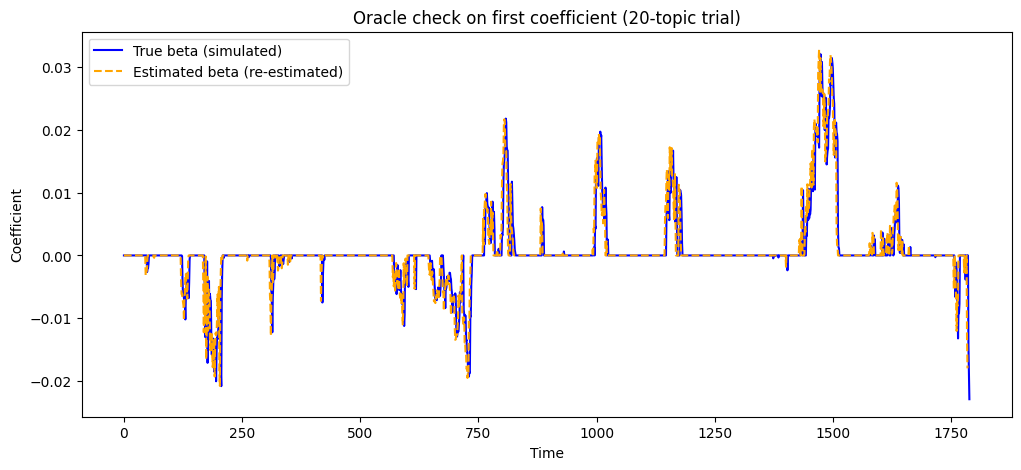

In [11]:
# Quick visual diagnostic for first coefficient in 20-topic trial
beta_true_20_2d = beta_true_20[:, :, 0]
beta_est_20 = details_20[[c for c in details_20.columns if c.startswith('Lasso_')]].to_numpy()
common_t_20 = min(beta_true_20_2d.shape[0], beta_est_20.shape[0])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(beta_true_20_2d[-common_t_20:, 0], label='True beta (simulated)', color='blue')
ax.plot(beta_est_20[-common_t_20:, 0], label='Estimated beta (re-estimated)', color='orange', linestyle='--')
ax.set_title('Oracle check on first coefficient (20-topic trial)')
ax.set_xlabel('Time')
ax.set_ylabel('Coefficient')
ax.legend()
plt.show()

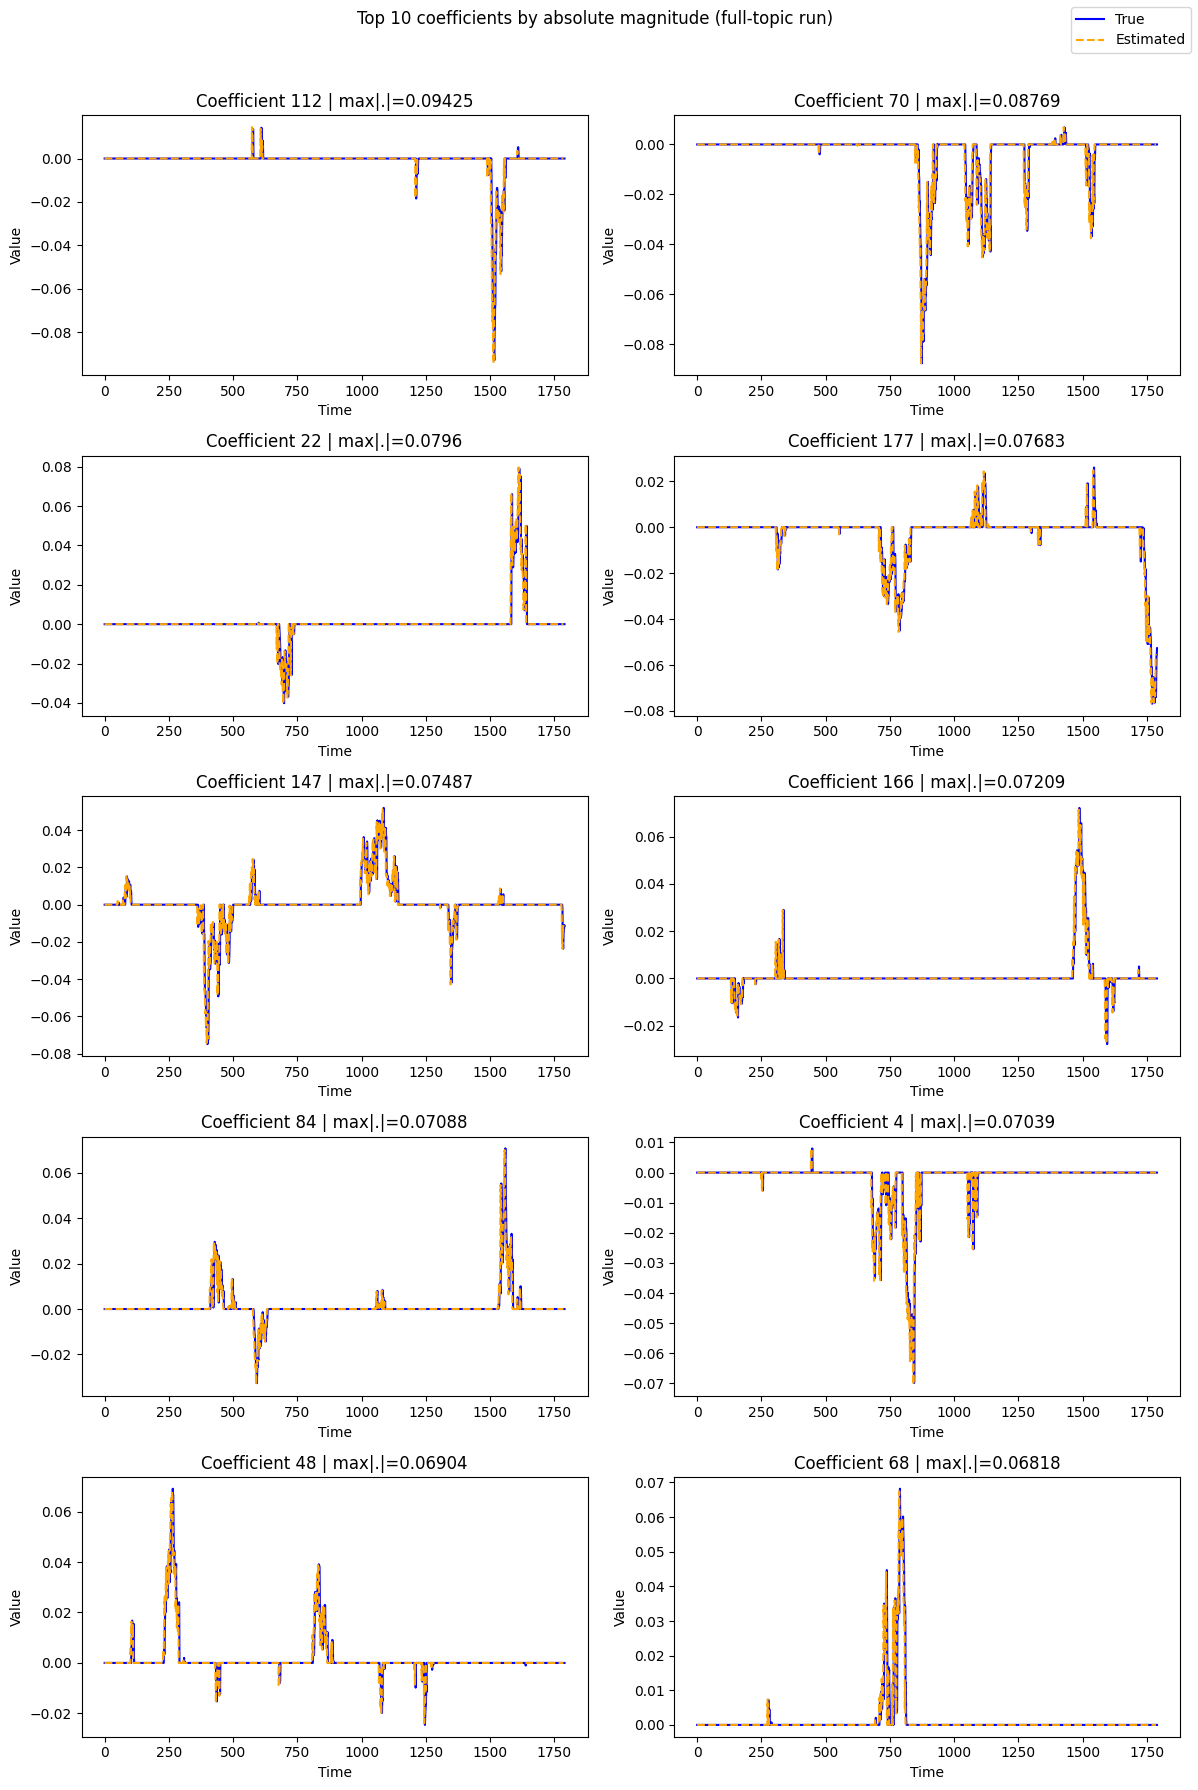

In [12]:
# Plot top 10 coefficients by largest absolute value (full-topic run)
beta_true_full_2d = beta_true_full[:, :, 0]
beta_est_full = details_full[[c for c in details_full.columns if c.startswith('Lasso_')]].to_numpy()
common_t_full = min(beta_true_full_2d.shape[0], beta_est_full.shape[0])

true_aligned = beta_true_full_2d[-common_t_full:, :]
est_aligned = beta_est_full[-common_t_full:, :]

# Rank coefficients by largest absolute value across time (NaN-safe)
abs_true = np.abs(true_aligned)
abs_est = np.abs(est_aligned)

score_true = np.nanmax(abs_true, axis=0)
score_est = np.nanmax(abs_est, axis=0)
score = np.maximum(score_true, score_est)

# Replace non-finite scores so they are excluded from top selection
score_clean = np.where(np.isfinite(score), score, -np.inf)
valid_idx = np.where(score_clean > -np.inf)[0]

if len(valid_idx) == 0:
    print('No finite coefficient paths available to rank.')
else:
    top_n = min(10, len(valid_idx))
    top_idx = valid_idx[np.argsort(score_clean[valid_idx])[-top_n:][::-1]]

    n_cols = 2
    n_rows = int(np.ceil(len(top_idx) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), squeeze=False)

    for plot_i, coef_i in enumerate(top_idx):
        r, c = divmod(plot_i, n_cols)
        ax = axes[r, c]
        ax.plot(true_aligned[:, coef_i], label='True', color='blue')
        ax.plot(est_aligned[:, coef_i], label='Estimated', color='orange', linestyle='--')
        ax.set_title(f'Coefficient {coef_i} | max|.|={score_clean[coef_i]:.4g}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Value')

    for k in range(len(top_idx), n_rows * n_cols):
        r, c = divmod(k, n_cols)
        axes[r, c].axis('off')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    fig.suptitle('Top 10 coefficients by absolute magnitude (full-topic run)', y=1.02)
    plt.tight_layout()
    plt.show()

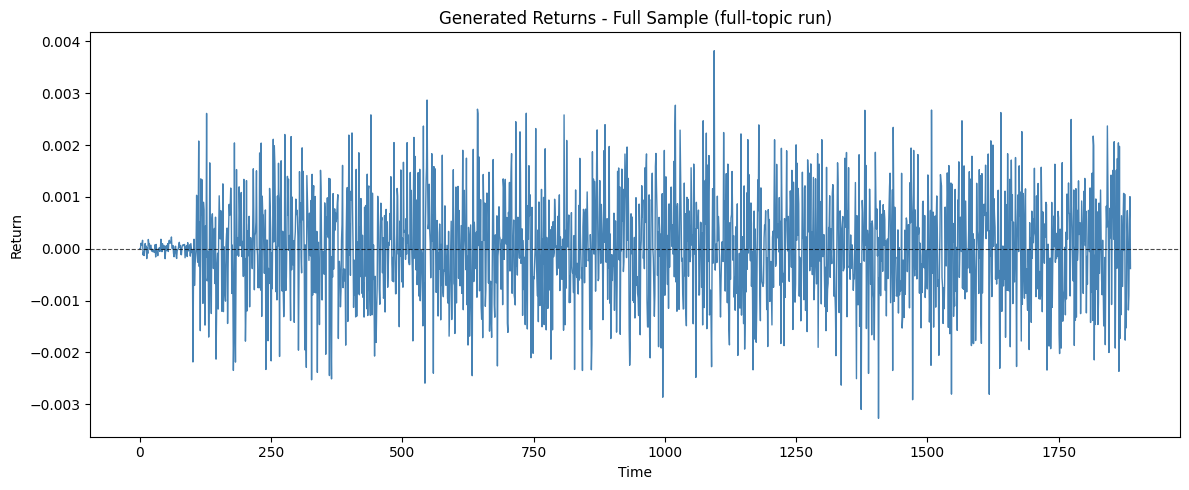

In [13]:
# Plot generated returns (full sample, full-topic run)
_, r_generated_full, _ = multivariate_CGL_offline_lasso_with_X(
    X=topics.to_numpy(),
    sigma=sigma,
    kappa=kappa,
    w=w,
    rolling_window_size=window_size,
    lambda_lasso=lambda_val,
    correct_with_tanh=correct_with_tanh,
    random_seed=12
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(r_generated_full, color='steelblue', linewidth=1)
ax.set_title('Generated Returns - Full Sample (full-topic run)')
ax.set_xlabel('Time')
ax.set_ylabel('Return')
ax.axhline(0.0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# Empirical vs analytical selection probability (full-topic run)
beta_cols_full = [c for c in details_full.columns if c.startswith('Lasso_')]
beta_mat_full = details_full[beta_cols_full].to_numpy()

# 1) Overall selection proportion across all topic-time cells
overall_selection_prop = float(np.mean(beta_mat_full != 0.0))

# 2) Per-topic selection proportions, then average
per_topic_selection_prop = (beta_mat_full != 0.0).mean(axis=0)
avg_topic_selection_prop = float(per_topic_selection_prop.mean())

# 3) Window-level proportion selected (fraction of active topics each date)
per_time_selection_prop = (beta_mat_full != 0.0).mean(axis=1)
avg_time_selection_prop = float(per_time_selection_prop.mean())

n_topics_full = beta_mat_full.shape[1]
expected_active_topics_from_target = target_selection_prob * n_topics_full
observed_active_topics_avg = float((beta_mat_full != 0.0).sum(axis=1).mean())

print(f"Analytical target selection probability: {target_selection_prob:.4f}")
print(f"Empirical overall selection proportion:  {overall_selection_prop:.4f}")
print(f"Empirical avg per-topic proportion:      {avg_topic_selection_prop:.4f}")
print(f"Empirical avg per-time proportion:       {avg_time_selection_prop:.4f}")
print(f"Expected active topics per window (target): {expected_active_topics_from_target:.2f}")
print(f"Observed active topics per window (avg):     {observed_active_topics_avg:.2f}")

comparison_selection = pd.DataFrame({
    'metric': [
        'target_probability',
        'empirical_overall_probability',
        'empirical_avg_per_topic_probability',
        'empirical_avg_per_time_probability',
        'expected_active_topics_per_window',
        'observed_active_topics_per_window'
    ],
    'value': [
        target_selection_prob,
        overall_selection_prop,
        avg_topic_selection_prop,
        avg_time_selection_prop,
        expected_active_topics_from_target,
        observed_active_topics_avg
    ]
})
comparison_selection

Analytical target selection probability: 0.0200
Empirical overall selection proportion:  0.1004
Empirical avg per-topic proportion:      0.1004
Empirical avg per-time proportion:       0.1004
Expected active topics per window (target): 3.60
Observed active topics per window (avg):     18.07


,metric,value
0,target_probability,0.020000
1,empirical_overall_probability,0.100382
2,empirical_avg_per_topic_probability,0.100382
3,empirical_avg_per_time_probability,0.100382
4,expected_active_topics_per_window,3.600000
5,observed_active_topics_per_window,18.068715
